In [1]:
cd D:\VSCODE\Revolut

D:\VSCODE\Revolut


### 1. IMPORTS

In [2]:
# Libaries and importing data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

### 2. LOAD DATA

In [3]:
users = pd.read_csv('users.csv')
transactions = pd.read_csv('transactions.csv')
countries = pd.read_csv('countries.csv')
currency = pd.read_csv('currency_details.csv')

### 3. EDA — USERS
Initial exploration of user characteristics.
We start by understanding who the fraudsters are before looking at what they do.
Key findings:
- 298 fraudsters out of 9,944 users — roughly 3% of the dataset
- PENDING KYC users have the highest fraud rate at 21%
- Fraudsters are more likely to have a verified email, suggesting sophisticated profile setup
- Failed sign in attempts are twice as high among fraudsters, a potential account takeover signal

In [4]:
# Class distribution
users['IS_FRAUDSTER'].value_counts()

IS_FRAUDSTER
False    9646
True      298
Name: count, dtype: int64

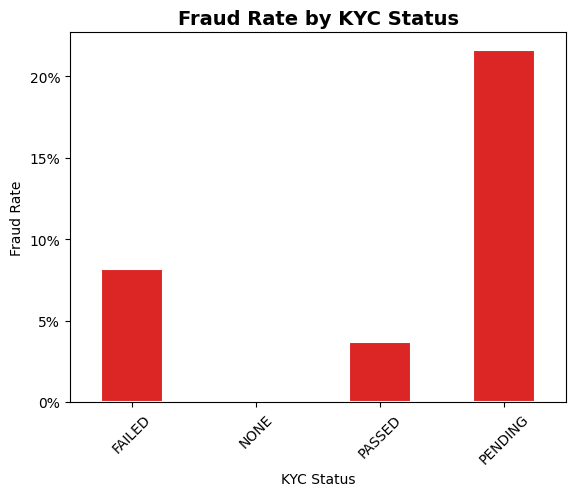

In [5]:
# Fraud rate by KYC status (normalized)
users.groupby('KYC')['IS_FRAUDSTER'].mean().plot(
    kind='bar',
    color='#DC2626',
    edgecolor='white',
    linewidth=1.5
)
plt.title('Fraud Rate by KYC Status', fontsize=14, fontweight='bold')
plt.xlabel('KYC Status')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.show()

In [6]:
# Fraud rate by HAS_EMAIL
users.groupby('HAS_EMAIL')['IS_FRAUDSTER'].mean()

HAS_EMAIL
0    0.001887
1    0.031549
Name: IS_FRAUDSTER, dtype: float64

In [7]:
# Failed sign in attempts by fraud status
users.groupby('IS_FRAUDSTER')['FAILED_SIGN_IN_ATTEMPTS'].mean()

IS_FRAUDSTER
False    0.007775
True     0.016779
Name: FAILED_SIGN_IN_ATTEMPTS, dtype: float64

In [8]:
# Birth year by fraud status
users.groupby('IS_FRAUDSTER')['BIRTH_YEAR'].mean()

IS_FRAUDSTER
False    1983.438627
True     1987.265101
Name: BIRTH_YEAR, dtype: float64

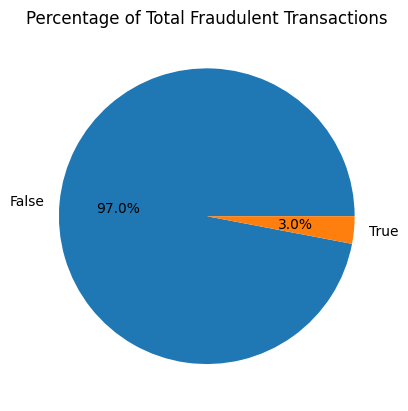

IS_FRAUDSTER
False    9646
True      298
Name: count, dtype: int64

In [9]:
users['IS_FRAUDSTER'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Percentage of Total Fraudulent Transactions')
plt.show()

users['IS_FRAUDSTER'].value_counts()

### 4. EDA — TRANSACTIONS
We tag each transaction with the fraud label without merging both datasets fully,
to avoid redundancy and memory inefficiency.
Key findings:
- CARD_PAYMENT dominates legitimate users (63.8%) but drops among fraudsters (45.9%)
- Fraudsters overindex on TOPUP and ATM transactions
- Fraudsters transact less frequently, likely because accounts get blocked quickly

In [10]:
transactions

,CURRENCY,AMOUNT,STATE,CREATED_DATE,MERCHANT_CATEGORY,MERCHANT_COUNTRY,ENTRY_METHOD,USER_ID,TYPE,SOURCE,ID,AMOUNT_USD
0,GBP,4420,COMPLETED,2017-12-10 16:38:55.577,NaN,NLD,chip,3ff52b92-d416-4e22-8cad-018f500d4bbc,ATM,GAIA,367bf5f9-7cce-4683-90b9-d3c011bf4c87,3268.0
1,PLN,1500,COMPLETED,2017-12-10 16:37:24.792,point_of_interest,POL,manu,76cbaad3-4721-4a3b-92b9-3eb9e9319565,CARD_PAYMENT,GAIA,ff6802b9-360d-4efe-b09b-f99c6cac3383,NaN
2,GBP,191,COMPLETED,2017-12-10 16:37:16.234,airport,PRT,chip,7bcaa34e-b889-4582-9c29-0b3bab34fb8c,CARD_PAYMENT,GAIA,ddb4a930-7d8a-4f38-9079-ddc4b0db980e,141.0
3,GBP,10000,COMPLETED,2017-12-10 16:34:42.592,NaN,NaN,misc,b3a6762b-a940-4459-bb1d-8e28e151f901,TOPUP,HERA,080ef0be-850a-4f14-ab03-28ff68e6b797,7394.0
4,EUR,1159,COMPLETED,2017-12-10 16:34:17.88,NaN,FRA,manu,f5723f5e-5a00-4851-ae1d-5c11146aa491,CARD_PAYMENT,GAIA,bd13abac-4004-4c67-9bb7-90a42b027e82,977.0
...,...,...,...,...,...,...,...,...,...,...,...,...
688646,GBP,1727,COMPLETED,2017-12-10 16:31:45.239,point_of_interest,USA,mags,80431c45-ffdb-4399-959b-7bc400d7ea54,CARD_PAYMENT,GAIA,021ebd5d-3b1f-4133-a94a-b3b7b07500c8,1277.0
688647,GBP,1807,COMPLETED,2017-12-10 16:30:42.774,NaN,LUX,manu,c2b50874-5091-44be-969c-6e3b4578f668,CARD_PAYMENT,GAIA,2fb06b3e-8778-4681-a039-fd852eb67352,1332.0
688648,EUR,3465,COMPLETED,2017-12-10 16:30:34.972,supermarket,LTU,chip,3f8c39e2-8970-4d25-bd3f-733bb5b4c3cd,CARD_PAYMENT,GAIA,053ff016-4628-4507-b65b-b1514a74836d,2915.0
688649,EUR,5000,COMPLETED,2017-12-10 16:30:23.285,NaN,NaN,misc,a2e41203-a8f5-4744-97ca-dfb04479cde9,TOPUP,HERA,c3c9caec-bb96-4b6c-8af0-f4353086baf3,4207.0


In [11]:
# Tag each transaction with fraud label
fraudster_ids = set(users.loc[users['IS_FRAUDSTER'] == True, 'ID'])
transactions['is_fraudster_tf'] = transactions['USER_ID'].isin(fraudster_ids)

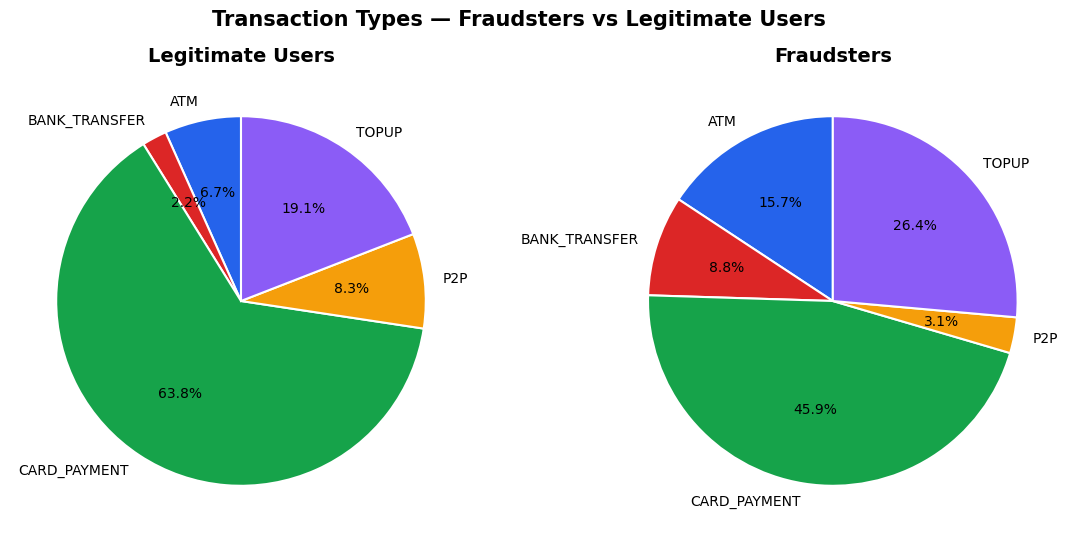

In [12]:
# Transaction type distribution — fraudsters vs legitimate
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

transactions[transactions['is_fraudster_tf'] == False].groupby('TYPE').size().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[0],
    colors=['#2563EB', '#DC2626', '#16A34A', '#F59E0B', '#8B5CF6'],
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Legitimate Users', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

transactions[transactions['is_fraudster_tf'] == True].groupby('TYPE').size().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[1],
    colors=['#2563EB', '#DC2626', '#16A34A', '#F59E0B', '#8B5CF6'],
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Fraudsters', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Transaction Types — Fraudsters vs Legitimate Users', fontsize=15, fontweight='bold')
plt.show()


In [13]:
# Average amount by fraud status
transactions.groupby('is_fraudster_tf')['AMOUNT'].mean()

is_fraudster_tf
False    31751.352503
True     30484.140218
Name: AMOUNT, dtype: float64

In [14]:
# Transaction frequency per user
transactions.groupby(['USER_ID', 'is_fraudster_tf']).size().groupby('is_fraudster_tf').mean()

is_fraudster_tf
False    87.355904
True     46.848485
dtype: float64

In [15]:
# Currency diversity per user
transactions.groupby(['USER_ID', 'is_fraudster_tf'])['CURRENCY'].nunique().groupby('is_fraudster_tf').mean()

is_fraudster_tf
False    1.680606
True     1.198653
Name: CURRENCY, dtype: float64

### 5. FEATURE ENGINEERING — TRANSACTION LEVEL

We build a user-level feature set combining signals from both datasets.
Each feature is grounded in a fraud behavior hypothesis.

User-level features:
- KYC status — risk indicator based on verification level
- Failed sign in attempts — account takeover signal
- Birth year — age pattern among fraudsters
- Has email — profile completeness

Transaction-level features:
- Total transactions — activity level
- Average amount — spending pattern
- Unique currencies — geographic diversity
- ATM/TOPUP ratio — transaction type behavior
- Average hour — time of day activity
- Transactions per day — burst behavior signal

In [16]:
transactions['CREATED_DATE'] = pd.to_datetime(transactions['CREATED_DATE'], format='mixed')
transactions['hour'] = transactions['CREATED_DATE'].dt.hour
transactions['date'] = transactions['CREATED_DATE'].dt.date

user_features = transactions.groupby('USER_ID').agg(
    total_transactions=('USER_ID', 'count'),
    avg_amount=('AMOUNT', 'mean'),
    unique_currencies=('CURRENCY', 'nunique'),
    atm_topup_ratio=('TYPE', lambda x: (x.isin(['ATM', 'TOPUP'])).mean()),
    avg_hour=('hour', 'mean'),
    transactions_per_day=('date', lambda x: len(x) / x.nunique())
).reset_index()

### 5.2 FEATURE ENGINEERING — USER LEVEL

In [17]:
# Convert dates
users['CREATED_DATE'] = pd.to_datetime(users['CREATED_DATE'])

In [18]:
# KYC encoding
kyc_mapping = {'NONE': 0, 'PENDING': 1, 'FAILED': 2, 'PASSED': 3}
users['KYC_encoded'] = users['KYC'].map(kyc_mapping)

In [19]:
# Merge user features into user_features dataframe
user_features = user_features.merge(
    users[['ID', 'KYC_encoded', 'HAS_EMAIL', 'FAILED_SIGN_IN_ATTEMPTS', 'BIRTH_YEAR', 'IS_FRAUDSTER']],
    left_on='USER_ID', right_on='ID', how='left'
)


In [20]:
# Drop unmatched users and clean up
user_features = user_features.dropna(subset=['IS_FRAUDSTER'])

### 6. MODELLING
We train three models of increasing complexity.
Class imbalance (3% fraud) is addressed via class_weight='balanced'.
Decision threshold lowered to 0.3 to prioritize recall,
missing a fraudster is more costly than a false alarm.

In [21]:
feature_cols = ['total_transactions', 'avg_amount', 'unique_currencies',
                'atm_topup_ratio', 'KYC_encoded', 'HAS_EMAIL',
                'FAILED_SIGN_IN_ATTEMPTS', 'BIRTH_YEAR',
                'avg_hour', 'transactions_per_day']

X = user_features[feature_cols]
y = user_features['IS_FRAUDSTER'].astype(int)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

In [25]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    train_score = model.score(X_train_scaled, y_train)
    test_score = model.score(X_test_scaled, y_test)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_proba >= 0.3).astype(int)
    print(f"\n{name}")
    print(f"Train accuracy: {train_score:.4f} | Test accuracy: {test_score:.4f}")
    print(classification_report(y_test, y_pred, digits=4))


Logistic Regression
Train accuracy: 0.7123 | Test accuracy: 0.7290
              precision    recall  f1-score   support

           0     0.9929    0.4370    0.6069      2229
           1     0.0662    0.9271    0.1236        96

    accuracy                         0.4572      2325
   macro avg     0.5295    0.6820    0.3652      2325
weighted avg     0.9546    0.4572    0.5869      2325


Random Forest
Train accuracy: 1.0000 | Test accuracy: 0.9647
              precision    recall  f1-score   support

           0     0.9731    0.9883    0.9806      2229
           1     0.5738    0.3646    0.4459        96

    accuracy                         0.9626      2325
   macro avg     0.7734    0.6765    0.7132      2325
weighted avg     0.9566    0.9626    0.9586      2325


Gradient Boosting
Train accuracy: 0.9788 | Test accuracy: 0.9669
              precision    recall  f1-score   support

           0     0.9748    0.9892    0.9820      2229
           1     0.6190    0.4062    0.49

### 7. HYPERPARAMETER TUNING
GridSearchCV with 5-fold cross validation, optimizing for recall.
Best models selected for final evaluation.

In [26]:
param_grids = {
    'Logistic Regression': {
        'model': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, 15],
            'min_samples_leaf': [1, 5, 10]
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2]
        }
    }
}

best_models = {}

for name, config in param_grids.items():
    print(f"\nTuning {name}...")
    grid_search = GridSearchCV(
        config['model'],
        config['params'],
        scoring='recall',
        cv=5,
        n_jobs=-1
    )
    grid_search.fit(X_train_scaled, y_train)
    best_models[name] = grid_search.best_estimator_
    print(f"Best params: {grid_search.best_params_}")
    print(f"Best recall (CV): {grid_search.best_score_:.4f}")


Tuning Logistic Regression...
Best params: {'C': 0.1}
Best recall (CV): 0.6918

Tuning Random Forest...
Best params: {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 100}
Best recall (CV): 0.6524

Tuning Gradient Boosting...
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best recall (CV): 0.2940


In [27]:
for name, model in best_models.items():
    train_score = model.score(X_train_scaled, y_train)
    test_score = model.score(X_test_scaled, y_test)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_proba >= 0.3).astype(int)
    print(f"\n{name}")
    print(f"Train accuracy: {train_score:.4f} | Test accuracy: {test_score:.4f}")
    print(classification_report(y_test, y_pred, digits=4))


Logistic Regression
Train accuracy: 0.7107 | Test accuracy: 0.7282
              precision    recall  f1-score   support

           0     0.9928    0.4325    0.6025      2229
           1     0.0657    0.9271    0.1228        96

    accuracy                         0.4529      2325
   macro avg     0.5293    0.6798    0.3626      2325
weighted avg     0.9545    0.4529    0.5827      2325


Random Forest
Train accuracy: 0.9226 | Test accuracy: 0.9178
              precision    recall  f1-score   support

           0     0.9911    0.6958    0.8176      2229
           1     0.1079    0.8542    0.1916        96

    accuracy                         0.7024      2325
   macro avg     0.5495    0.7750    0.5046      2325
weighted avg     0.9546    0.7024    0.7918      2325


Gradient Boosting
Train accuracy: 0.9865 | Test accuracy: 0.9665
              precision    recall  f1-score   support

           0     0.9734    0.9861    0.9797      2229
           1     0.5373    0.3750    0.44

## 8. Results & Model Selection
Random Forest selected as the final model.
Best balance between recall (0.85) and precision (0.11) after tuning.
Overfitting resolved through max_depth and min_samples_leaf constraints